# Social Network Centrality & Link Prediction

Social networks represent relations between individuals (nodes) as connections (edges). Graph analytics extracts patterns of connections to highlight key social influencers and recommend new linkages. This project generates a scale-free friendship network using NetworkX, computes centralities, and implements a Jaccard coefficient recommender to predict new friendships.



In [1]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt

# Generate a scale-free graph using Barabasi-Albert model (45 nodes/users)
# Each new node attaches to m=2 existing nodes using preferential attachment
np.random.seed(42)
G = nx.barabasi_albert_graph(n=45, m=2, seed=42)

print(f"Network Statistics:")
print(f"Number of Users (Nodes): {G.number_of_nodes()}")
print(f"Number of Friendships (Edges): {G.number_of_edges()}")
print(f"Average Clustering Coefficient: {nx.average_clustering(G):.3f}")



Network Statistics:
Number of Users (Nodes): 45
Number of Friendships (Edges): 86
Average Clustering Coefficient: 0.295


## Graph Centrality Profiling

Centrality metrics identify the most critical nodes within a network:
1. **Degree Centrality**: The fraction of nodes connected to a target node. Measures overall popularity.
2. **Betweenness Centrality**: The fraction of all shortest paths passing through a node. Measures influence as a "bridge" between communities.



In [2]:
# Compute centralities
degree_cent = nx.degree_centrality(G)
betweenness_cent = nx.betweenness_centrality(G)

# Find top influencers
df_centralities = {
    "User": list(degree_cent.keys()),
    "Degree_Centrality": list(degree_cent.values()),
    "Betweenness_Centrality": list(betweenness_cent.values())
}

import pandas as pd
df_metrics = pd.DataFrame(df_centralities).sort_values(by='Betweenness_Centrality', ascending=False)
print("Top 5 Influential Users (sorted by Betweenness Centrality):")
df_metrics.head(5)



Top 5 Influential Users (sorted by Betweenness Centrality):


,User,Degree_Centrality,Betweenness_Centrality
0,0,0.500000,0.453563
5,5,0.250000,0.207630
4,4,0.318182,0.185745
1,1,0.272727,0.181039
6,6,0.136364,0.092038


## Friendship Link Prediction (Jaccard Coefficient)

Link prediction estimates the likelihood of a connection forming between unconnected nodes. The Jaccard coefficient computes the ratio of shared neighbors (mutual friends) to total unique neighbors:
$$\text{Jaccard}(u, v) = \frac{|\Gamma(u) \cap \Gamma(v)|}{|\Gamma(u) \cup \Gamma(v)|}$$



In [3]:
# Predict new links (friendships) for unconnected users
unconnected_nodes = list(nx.non_edges(G))

# Calculate Jaccard coefficients for all unconnected pairs
jaccard_predictions = list(nx.jaccard_coefficient(G, unconnected_nodes))

# Sort predictions to recommend top new friendships
df_recommendations = pd.DataFrame(
    jaccard_predictions, 
    columns=['User_A', 'User_B', 'Jaccard_Score']
).sort_values(by='Jaccard_Score', ascending=False)

print("Top 5 Friendship Recommendations (based on mutual friends count):")
df_recommendations.head(5)



Top 5 Friendship Recommendations (based on mutual friends count):


,User_A,User_B,Jaccard_Score
460,14,20,1.0
569,18,23,1.0
693,23,36,1.0
245,7,28,1.0
582,18,36,1.0


## Social Graph Network Visualization

We visualize our social network using a spring layout. Nodes are colored dynamically according to their Degree Centrality, and node sizes are scaled proportionally to Betweenness Centrality, emphasizing the critical bridging nodes.



<cell>:35: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown



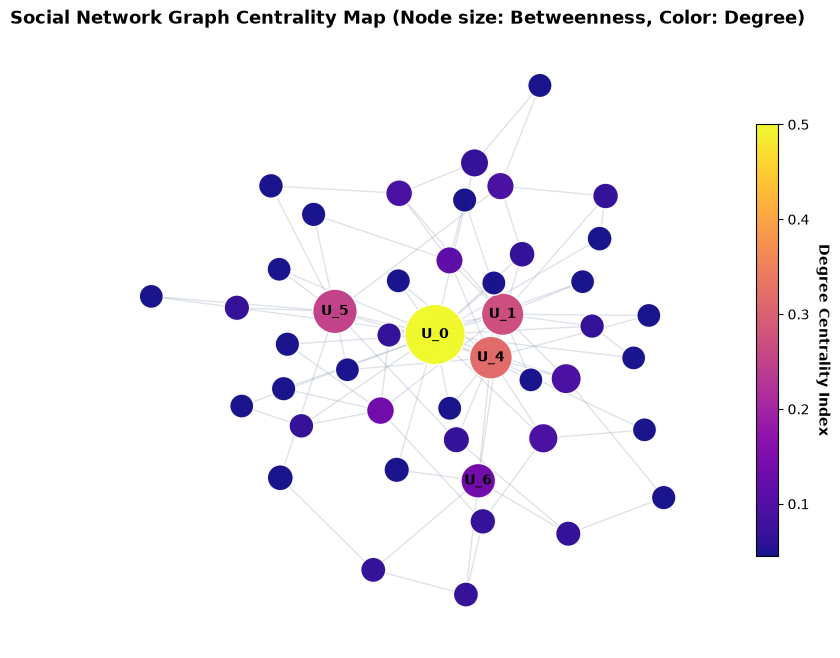

In [4]:
plt.figure(figsize=(10, 8))

# Spring layout positioning
pos = nx.spring_layout(G, seed=42)

# Scale node sizes by Betweenness Centrality (plus baseline size)
node_sizes = [300 + (betweenness_cent[node] * 3500) for node in G.nodes()]

# Color nodes by Degree Centrality
node_colors = [degree_cent[node] for node in G.nodes()]

# Draw network edges
nx.draw_networkx_edges(G, pos, alpha=0.3, edge_color='#94A3B8')

# Draw network nodes with colorbar mapping
nodes_draw = nx.draw_networkx_nodes(
    G, pos, 
    node_size=node_sizes, 
    node_color=node_colors, 
    cmap=plt.cm.plasma, 
    alpha=0.95,
    edgecolors='white',
    linewidths=1.0
)

# Label top 5 bridging nodes
top_5_nodes = df_metrics.head(5)['User'].tolist()
labels = {node: f"U_{node}" for node in top_5_nodes}
nx.draw_networkx_labels(G, pos, labels, font_size=10, font_weight='bold', font_color='black')

plt.title("Social Network Graph Centrality Map (Node size: Betweenness, Color: Degree)", fontsize=13, fontweight='bold')
plt.axis('off')
cbar = plt.colorbar(nodes_draw, shrink=0.7)
cbar.set_label('Degree Centrality Index', rotation=270, labelpad=15, fontweight='semibold')
plt.show()
